**Ch121a | Module 3: Periodic DFT**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ppt-2/Ch121a-DFT/blob/main/Module3_Periodic-DFT/notebooks/03b_bader_neb_metadynamics.ipynb)

# Notebook 3b: Bader Charges, Reaction Mechanisms & Enhanced Sampling in pwDFT

---

## Learning Objectives

- Bader charge analysis, post-DFT
- Reaction mechanisms and energy profiles from plane-wave pwDFT
- Nudged Elastic Band (NEB) method
- Climbing-Image NEB (CI-NEB) for accurate transition-state location
- Improved/Reduced Dimer Method for open-ended transition-state search
- Metadynamics simulations in VASP for free-energy landscapes
    
> **Prerequisites:** Notebooks 3a (VASP input files, workflows), 4a–4b (energy calculations)

## 1. Bader Charge Analysis

### 1.1 What Are Bader Charges?

When atoms bond, electrons redistribute. **Bader charge analysis** is a rigorous, grid-based method to partition the continuous electron density of a periodic DFT calculation into atomic contributions — no empirical parameters required.

Developed by Richard Bader ("Atoms in Molecules", AIM theory), the key idea is:

> **Divide 3-D space into atomic basins separated by zero-flux surfaces in ∇ρ(r).**  
> Each basin contains exactly one nucleus. Integrate ρ(r) inside each basin → atomic charge.

$$Q_\text{Bader}^A = Z_A - \int_{\Omega_A} \rho(\mathbf{r})\, d^3r$$

where $Z_A$ is the nuclear charge and $\Omega_A$ is the basin of atom $A$.

**Why use it over Mulliken/Löwdin charges?**

| Method | Basis-set dependent? | Periodic? | Well-defined? |
|--------|---------------------|-----------|---------------|
| Mulliken | ✅ Yes (strongly) | ✅ Yes | ⚠️ No |
| Löwdin | ✅ Yes | ✅ Yes | ⚠️ No |
| Bader/AIM | ❌ No | ✅ Yes | ✅ Yes |

Bader charges are **reproducible**, **basis-set independent**, and work naturally on the real-space grid that VASP (in CHGCAR file) or QE already outputs.

### 1.2 Physical Picture: Zero-Flux Surfaces

```
        ρ(r) contours                Gradient field ∇ρ

         ···                           ↑ ↑ ↑
       ·· A ··                        ↑ A ↑          ╌╌╌╌╌ zero-flux surface
         ···                           ↑ ↑ ↑
  ───────────────── ← surface     ←←←←┼→→→→→
         ···                           ↓ ↓ ↓
       ·· B ··                        ↓ B ↓
         ···                           ↓ ↓ ↓
```

The surface is defined by: $\nabla \rho(\mathbf{r}) \cdot \hat{n}(\mathbf{r}) = 0$ everywhere on it.

This is where the electron density has a saddle point between two atoms — usually close to the bond critical point (BCP).

### 1.3 Practical Workflow (VASP + Henkelman code)

The most widely used Bader analysis code is from the **Henkelman group** (UT Austin), freely available at [theory.cm.utexas.edu/henkelman/code/bader](http://theory.cm.utexas.edu/henkelman/code/bader/).
[VASP-tst code, scripts for charge summation and also later for NEB](https://vtstools.readthedocs.io/en/latest/download.html)
**Step 1: Run a standard VASP calculation with increased charge-density grid.**

The charge-density grid must be fine enough to accurately locate zero-flux surfaces. Add these INCAR tags:

```
LAECHG = .TRUE.    ! Write AECCAR0 (core) and AECCAR2 (valence) charge densities
LCHARG = .TRUE.    ! Write CHGCAR
NGXF   = 3*NGX     ! Triple the FFT grid in x (use 3× default for accuracy)
NGYF   = 3*NGY
NGZF   = 3*NGZ
```

> **Why LAECHG?**  VASP PAW calculations normally only store valence electron density. `LAECHG` writes the reconstructed all-electron charge density — essential for accurate Bader integration (especially for core-valence charge transfer in oxides).

**Step 2: Add core + valence charge densities**

```bash
# After the VASP run completes:
chgsum.pl AECCAR0 AECCAR2   # Henkelman utility: outputs CHGCAR_sum
```

**Step 3: Run Bader analysis**

```bash
bader CHGCAR -ref CHGCAR_sum
```

**Step 4: Read the output**

```
ACF.dat   — Bader charges per atom (column: #, x, y, z, charge, min-dist, atomic-vol)
BCF.dat   — Basin charge file
AtomVolumes.dat — Bader volumes
```

Example `ACF.dat` snippet for NiO:
```
    #    X         Y         Z        CHARGE    MIN DIST   ATOMIC VOL
    1  0.000    0.000    0.000    9.415      1.201      11.23    ← Ni  (expected ~10e)
    2  2.085    2.085    2.085    7.585      0.982       8.47    ← O   (expected ~6e neutral)
```

**Charge transfer** = formal charge − Bader charge:
- Ni: 10 − 9.415 = **+0.585 e** transferred (Ni²⁺ character)
- O: 6 − 7.585 = **−1.585 e** gained (O²⁻ character)


### 1.4 Analysis with Python


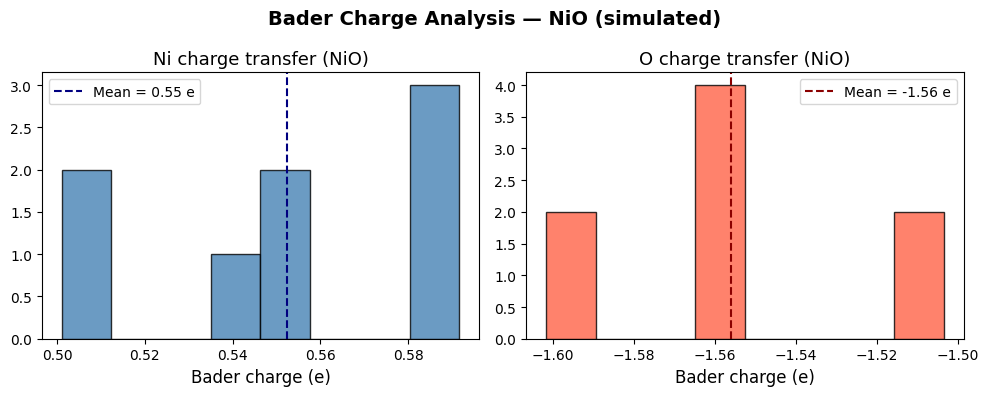

Ni: mean Bader charge = 0.552 e  (formal Ni²⁺ = +2.0 e)
O : mean Bader charge = -1.556 e  (formal O²⁻ = -2.0 e)

Note: Bader charges are partial — they reflect covalency, not purely ionic picture.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Parse ACF.dat ----------
def parse_acf(filename="ACF.dat"):
    """Read Henkelman bader ACF.dat and return array of charges."""
    charges = []
    with open(filename) as f:
        for line in f:
            line = line.strip()
            if not line or line.startswith('#') or line.startswith('-'):
                continue
            parts = line.split()
            if parts[0].isdigit():
                charges.append(float(parts[4]))   # column 5 = Bader charge
    return np.array(charges)

# ---------- Example: simulated NiO data ----------
# In a real workflow: charges = parse_acf("path/to/ACF.dat")
np.random.seed(42)
ni_charges = np.random.normal(9.42, 0.05, 8)   # 8 Ni atoms
o_charges  = np.random.normal(7.58, 0.04, 8)   # 8 O  atoms

# Nuclear charges (valence electrons in PAW):
Z_ni, Z_o = 10.0, 6.0

ni_bader_charge = Z_ni - ni_charges   # positive → Ni has lost electrons
o_bader_charge  = Z_o  - o_charges    # negative → O has gained electrons

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].hist(ni_bader_charge, bins=8, color='steelblue', edgecolor='k', alpha=0.8)
axes[0].axvline(ni_bader_charge.mean(), color='navy', ls='--',
                label=f'Mean = {ni_bader_charge.mean():.2f} e')
axes[0].set_xlabel('Bader charge (e)', fontsize=12)
axes[0].set_title('Ni charge transfer (NiO)', fontsize=13)
axes[0].legend()

axes[1].hist(o_bader_charge, bins=8, color='tomato', edgecolor='k', alpha=0.8)
axes[1].axvline(o_bader_charge.mean(), color='darkred', ls='--',
                label=f'Mean = {o_bader_charge.mean():.2f} e')
axes[1].set_xlabel('Bader charge (e)', fontsize=12)
axes[1].set_title('O charge transfer (NiO)', fontsize=13)
axes[1].legend()

plt.suptitle('Bader Charge Analysis — NiO (simulated)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Ni: mean Bader charge = {ni_bader_charge.mean():.3f} e  (formal Ni²⁺ = +2.0 e)")
print(f"O : mean Bader charge = {o_bader_charge.mean():.3f} e  (formal O²⁻ = -2.0 e)")
print("\nNote: Bader charges are partial — they reflect covalency, not purely ionic picture.")

### 1.5 Key Points & Common Pitfalls

| ✅ Do | ❌ Avoid |
|-------|----------|
| Use `LAECHG = .TRUE.` + add AECCAR0+AECCAR2 | Bader on valence-only CHGCAR (underestimates transfer) |
| Use fine grid (NGXF/NGYF/NGZF ≥ 3×default) | Default grid → inaccurate basin boundaries |
| Cite Henkelman et al., 2006 (CMS) + Tang et al., 2009 | — |
| Compare to formal oxidation states, not equal them | Expect ~50–80% of formal value for covalent systems |

**Applications:**
- Oxidation state assignment in complex oxides, MXenes, Co-PC (we used in this class for finite DFT too)
- Charge transfer at metal/support interfaces (e.g., Au on TiO₂)
- Tracking electron transfer along reaction coordinates
- Electronegativity-based descriptor development

---

## 2. Reaction Mechanisms from Plane-Wave DFT

### 2.1 The Central Questions

When studying a reaction on a surface or in the bulk, we need:

1. **Reactant and product geometries** — local minima on the potential energy surface (PES)
2. **Minimum energy path (MEP)** — the pathway connecting them through configuration space
3. **Transition state (TS)** — the highest-energy point along the MEP (first-order saddle point)
4. **Activation energy (Ea)** — the barrier height; enters rate constants via Arrhenius / TST

$$k(T) = A \, e^{-E_a / k_B T} \qquad (\text{Arrhenius})$$

$$k_\text{TST}(T) = \frac{k_B T}{h} \frac{Z_\text{TS}}{Z_\text{R}} \, e^{-\Delta E^\ddagger / k_B T}$$

### 2.2 Energy Profile Along a Reaction Coordinate

```
  Energy
  │                  TS ●
  │                 ╱    ╲
  │                ╱      ╲
  │  Reactants ●──╱        ╲──● Products
  │             
  └─────────────────────────────────────→  Reaction coordinate (path length s)
                   Ea (forward)
```

### 2.3 Typical Surface Reaction Workflow

```
1. Relax slab + molecule (separate)                VASP: IBRION=2, ISIF=2
   ↓
2. Adsorb molecule, relax → reactant state (IS)   NSW=200, EDIFFG=-0.02
   ↓
3. Move molecule to product geometry, relax → FS  (same settings)
   ↓
4. Interpolate images IS → FS                     VTST tools / ASE
   ↓
5. Run NEB / CI-NEB                               VASP + VTST
   ↓
6. Extract Ea, visualize MEP, confirm TS by       vaspkit / custom Python
   frequency analysis (1 imaginary mode)
```

### 2.4 Degrees of Freedom & Constraints

- **Selective dynamics** in POSCAR: fix bottom slab layers, relax top layer + adsorbate
- **Spin polarization**: essential for open-shell adsorbates (O₂, NO) and magnetic metals
- **vdW corrections** (DFT-D3, optB88-vdW): important when physisorption or weak chemisorption is involved

---

## 3. Nudged Elastic Band (NEB)

### 3.1 Core Idea

The **Nudged Elastic Band** method (Jónsson, Mills, Jacobsen, 1998) finds the minimum energy path (MEP) between two known endpoints by:

1. Creating a **chain of images** (intermediate geometries) between IS and FS
2. Connecting adjacent images with **spring forces** (elastic band)
3. **Projecting** ("nudging") forces to prevent the band from sliding off the MEP:
   - Spring forces act only **along** the band tangent (keep images evenly spaced)
   - True DFT forces act only **perpendicular** to the tangent (converge images onto MEP)

$$\mathbf{F}_i^\text{NEB} = \mathbf{F}_i^\perp + \mathbf{F}_i^\text{spring,||}$$

where:
- $\mathbf{F}_i^\perp = -\nabla E(\mathbf{R}_i) + [\nabla E(\mathbf{R}_i) \cdot \hat{\tau}_i]\hat{\tau}_i$ (true force minus component along tangent)
- $\mathbf{F}_i^\text{spring,||} = k[(|\mathbf{R}_{i+1}-\mathbf{R}_i| - |\mathbf{R}_i-\mathbf{R}_{i-1}|)]\hat{\tau}_i$ (spring along tangent)

### 3.2 Visual: NEB Images on a PES

```
  Energy surface
     ┌──────────────────────────────────────────┐
     │  IS ○─────●─────●─────●─────●─────○ FS  │
     │  image 0  1     2     3     4     5      │
     │           spring forces keep spacing     │
     │           DFT forces minimise energy ⊥   │
     └──────────────────────────────────────────┘
```

### 3.3 VASP + VTST Setup

VASP does not ship NEB natively. Use the **VTST** (Henkelman group) or **ASE** interface.

**Directory structure:**
```
neb_run/
  00/  POSCAR  ← initial state (IS)
  01/  POSCAR  ← image 1 (interpolated)
  02/  POSCAR  ← image 2
  ...
  0N/  POSCAR  ← final state (FS)
  INCAR  KPOINTS  POTCAR  (shared, in parent folder)
```

**Interpolation with ASE or VTST:**
```python
from ase.io import read, write
from ase.neb import NEB

initial = read('IS/POSCAR')
final   = read('FS/POSCAR')

images = [initial.copy() for _ in range(9)]   # 7 intermediate + 2 endpoints
images.append(final)

neb = NEB(images)
neb.interpolate(method='idpp')   # IDPP: Image-Dependent Pair Potential (better than linear)

for i, image in enumerate(images):
    write(f'{i:02d}/POSCAR', image)
```

**Key INCAR tags for NEB:**
```
ICHAIN  = 0        ! 0 = NEB, 1 = Dimer
IMAGES  = 7        ! Number of intermediate images (excludes endpoints)
SPRING  = -5.0     ! Spring constant (eV/Å²) — negative for nudging convention
LCLIMB  = .FALSE.  ! .TRUE. activates climbing image (Section 4)
IOPT    = 1        ! 1 = LBFGS optimizer (recommended for NEB)
EDIFF   = 1E-5
EDIFFG  = -0.05    ! Force convergence per image
NSW     = 200
IBRION  = 3        ! Damped molecular dynamics (used with VTST optimizers)
POTIM   = 0.0      ! Time step set by VTST optimizer
```


### 3.4 Post-Processing: MEP Plot

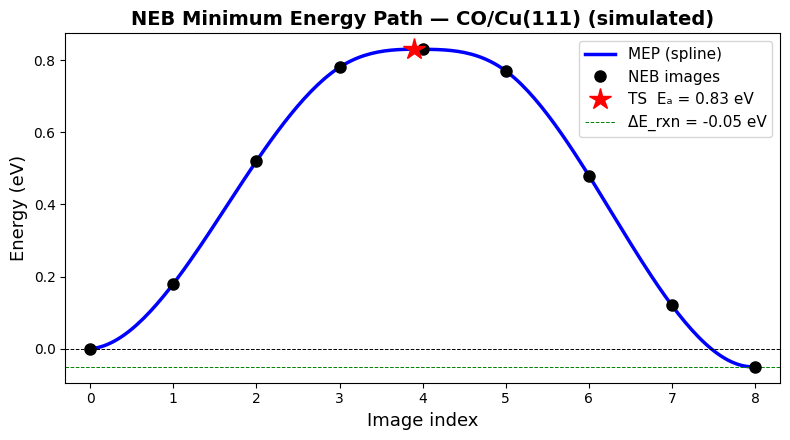

Activation energy (forward):  0.830 eV
Reaction energy ΔE:           -0.050 eV
Activation energy (reverse):  0.880 eV


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import CubicSpline

# ---------- Simulated NEB result ----------
# In a real workflow: read energies from each image's OSZICAR
n_images = 9   # includes endpoints
image_idx = np.arange(n_images)

# Simulated energies (eV) relative to IS for CO diffusion on Cu(111)
raw_energies = np.array([0.00, 0.18, 0.52, 0.78, 0.83, 0.77, 0.48, 0.12, -0.05])

# Cubic spline for smooth MEP
cs = CubicSpline(image_idx, raw_energies)
s_fine = np.linspace(0, n_images - 1, 200)
E_fine = cs(s_fine)

i_ts = np.argmax(E_fine)

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(s_fine, E_fine, 'b-', lw=2.5, label='MEP (spline)')
ax.plot(image_idx, raw_energies, 'ko', ms=8, zorder=5, label='NEB images')
ax.plot(s_fine[i_ts], E_fine[i_ts], 'r*', ms=16, zorder=6,
        label=f'TS  Eₐ = {E_fine[i_ts]:.2f} eV')
ax.axhline(0, color='k', lw=0.7, ls='--')
ax.axhline(raw_energies[-1], color='green', lw=0.7, ls='--',
           label=f'ΔE_rxn = {raw_energies[-1]:.2f} eV')
ax.set_xlabel('Image index', fontsize=13)
ax.set_ylabel('Energy (eV)', fontsize=13)
ax.set_title('NEB Minimum Energy Path — CO/Cu(111) (simulated)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.set_xlim(-0.3, n_images - 0.7)
plt.tight_layout()
plt.show()

print(f"Activation energy (forward):  {E_fine[i_ts]:.3f} eV")
print(f"Reaction energy ΔE:           {raw_energies[-1]:.3f} eV")
print(f"Activation energy (reverse):  {E_fine[i_ts] - raw_energies[-1]:.3f} eV")

### 3.5 NEB Convergence Tips

| Issue | Likely Cause | Fix |
|-------|-------------|-----|
| Band slides / corner-cutting | Spring too weak | Increase \|SPRING\| |
| Images cluster near endpoints | Spring too strong | Reduce \|SPRING\| |
| TS image has non-zero ∥ force | Standard NEB only | Use CI-NEB (Section 4) |
| Poor initial path | Linear interpolation | Use IDPP interpolation |
| One image stuck | Spin flip or symmetry break | Check OSZICAR, reset image |

**Number of images rule of thumb:** 1 image per 0.8–1.0 Å of path length (from POSCAR units).

---

## 4. Climbing-Image NEB (CI-NEB)

### 4.1 Motivation: Why Standard NEB Is Not Enough

In plain NEB, the **highest-energy image** is not exactly at the saddle point — it feels spring forces from neighbors and can be slightly off. The error is typically 0.05–0.1 eV but can be larger for sharp barriers.

**Climbing-Image NEB (CI-NEB)** (Henkelman, Uberuaga, Jónsson, JCP 2000) solves this elegantly:

> After the NEB converges (or semi-converges), identify the highest-energy image.  
> Modify its force: **remove spring forces entirely**, **invert** the component of the true force along the band tangent.  
> This image now *climbs uphill* along the tangent while minimizing energy perpendicular to it → it converges to the exact saddle point.

$$\mathbf{F}_i^\text{CI} = -\nabla E(\mathbf{R}_i) + 2[\nabla E(\mathbf{R}_i) \cdot \hat{\tau}_i]\hat{\tau}_i$$

(This is the full force with the tangential component sign-flipped.)

### 4.2 Visual Comparison

```
Standard NEB:                     CI-NEB:

  Energy                           Energy
  │         ●                      │         ★  ← climbing image
  │       ●   ●                    │       ●   ●
  │     ●       ●                  │     ●       ●
  │   ●           ●                │   ●           ●
  │ ●               ●              │ ●               ●
  └────────────────────→           └────────────────────→
    TS not at image, offset           TS = exact saddle point ★
```

### 4.3 INCAR Changes for CI-NEB

Only one line changes from standard NEB:

```
LCLIMB = .TRUE.    ! Activates climbing image
```

**Recommended protocol:**
1. Run standard NEB to get a good initial band (EDIFFG = −0.10 eV/Å)
2. Switch on LCLIMB, tighten convergence (EDIFFG = −0.05 eV/Å)
3. Verify: climbing image should have exactly **1 imaginary vibrational frequency** (run IBRION=5 on TS geometry)

### 4.4 Verifying the Transition State

After CI-NEB, always verify the TS by frequency analysis:

```
IBRION = 5        ! Finite-difference frequencies
NFREE  = 2        ! Central difference
NSW    = 0        ! No ionic relaxation
POTIM  = 0.015    ! Displacement step (Å)
```

A true first-order saddle point has **exactly one imaginary frequency** (shown as negative in OUTCAR), corresponding to the reaction mode.

```bash
grep 'f/i' OUTCAR   # imaginary frequencies listed as f/i
```

Example OUTCAR output:
```
 1 f  =   42.3 THz  →  real mode (surface phonon)
 2 f  =   38.1 THz  →  real mode
 ...
 N f/i=  312.5 cm-1 →  imaginary mode = reaction coordinate 
```

---

## 5. Improved/Reduced Dimer Method

### 5.1 When NEB Is Not Ideal

NEB/CI-NEB requires known IS **and** FS. Sometimes:
- The product is unknown (e.g., exploring all possible decomposition pathways)
- The reaction involves many coupled degrees of freedom (protein folding, bulk diffusion)
- You want to enumerate multiple saddle points from one minimum

→ Use a **single-ended** saddle-point search: the **Dimer Method**.

### 5.2 The Original Dimer Method (Henkelman & Jónsson, 1999)

Place two images (a "dimer") close together, separated by distance $2\Delta R$ along a direction $\hat{N}$.

**Algorithm:**
1. **Rotate** the dimer to align $\hat{N}$ with the lowest-curvature direction (softmode)
2. **Translate** the midpoint uphill along $\hat{N}$, downhill perpendicular to it
3. Repeat until forces converge → saddle point

```
         ●────────●      Dimer images separated by 2ΔR
         R₁   R₀   R₂
            ↑
            N̂ = direction of lowest curvature (concave up)
```

**Curvature estimate:**
$$C = \frac{(\mathbf{F}_1 - \mathbf{F}_2) \cdot \hat{N}}{2\Delta R}$$

The dimer aligns to minimize $C$ (most negative curvature = reaction mode).

### 5.3 Improved Dimer Method (Heyden, Bell, Keil, 2005)

The **Improved Dimer Method** reduces the number of force calls per rotation step by using a L-BFGS optimizer for both rotation and translation instead of gradient-descent. Key improvements:

- Fewer force evaluations per iteration (~30–50% reduction)
- More reliable convergence for systems with many soft modes
- Can use the same VTST VASP patch

### 5.4 VASP Setup for Dimer Method

Requires VTST patch. Key INCAR settings:

```
ICHAIN = 2        ! 2 = Dimer method
DdR    = 0.005    ! Dimer separation ΔR (Å) — use small value
DRotMax= 4        ! Max rotation steps per translation
DFNMin = 0.01     ! Rotational force tolerance
IOPT   = 2        ! CG optimizer for dimer translation
EDIFFG = -0.05    ! Convergence criterion
NSW    = 300
IBRION = 3
POTIM  = 0.0
```

**MODECAR:** Provide an initial displacement direction:
```
# MODECAR: displacement vector for each atom (one line per atom)
0.0  0.0  0.0   ← fixed atom
0.0  0.0  1.0   ← guess: adsorbate moving in z
0.0  0.0  0.0
...
```

**Comparison: NEB vs. Dimer vs. CI-NEB**

| | NEB | CI-NEB | Dimer |
|---|---|---|---|
| Requires product? | ✅ Yes | ✅ Yes | ❌ No |
| Finds exact TS? | ⚠️ Approx | ✅ Yes | ✅ Yes |
| Number of force calls | High | High | Medium |
| Good for | Known pathways | Precise barriers | Exploration |
| Implementation | VTST / ASE | VTST / ASE | VTST |

### 5.5 Practical Recommendations

- **Start with NEB/CI-NEB** when you know IS and FS — most reliable
- **Use Dimer** when exploring unknown mechanisms or checking for alternative paths
- **Combine both:** Dimer to find TS guess → CI-NEB to trace the full MEP
- Always verify with frequency analysis: one imaginary mode required

---

## 6. Metadynamics in VASP

### 6.1 The Problem: Rare Events

Standard AIMD (Ab-Initio Molecular Dynamics) runs at finite temperature but the simulation time is limited to **picoseconds** (VASP) to **nanoseconds** (ML force fields). Many chemically interesting events are **rare** on these timescales:

- Bond breaking / forming with barriers > ~0.5 eV
- Diffusion over saddle points in bulk or on surfaces
- Conformational transitions in adsorbates
- Nucleation events

**Standard MD at 300 K** cannot sample these — the system is trapped in minima.

### 6.2 Metadynamics: Core Idea

Developed by Laio & Parrinello (PNAS 2002), **metadynamics** accelerates rare event sampling by:

1. Defining one or more **collective variables (CVs)** that distinguish IS from FS (e.g., bond length, coordination number, angle)
2. Periodically adding small **Gaussian bias potentials** at the current CV value
3. The accumulated bias gradually **fills free-energy wells** → the system escapes and explores the landscape
4. The **negative of the accumulated bias** estimates the **free energy surface (FES)**

$$V_G(s, t) = W \sum_{t' < t} \exp\left(-\frac{(s - s(t'))^2}{2\sigma^2}\right)$$

where $W$ = Gaussian height, $\sigma$ = Gaussian width, $s$ = collective variable.

```
Free energy              Accumulated bias
  │  \                     │      ░░░░░░░░
  │   \   /\               │   ░░░░░░░░░░░░░
  │    \ /  \              │ ░░░░░░░░░░░░░░░░░
  │     V    \             │░░░░░░░░░░░░░░░░░░░
  └────────────→  CV       └────────────────────→  CV
    trapped in well           bias fills the well
```

### 6.3 Well-Tempered Metadynamics (WT-MetaD)

Standard metadynamics can overfill wells and is not guaranteed to converge. **Well-tempered metadynamics** (Barducci, Bussi, Parrinello, 2008) modulates the Gaussian height:

$$W(t) = W_0 \exp\left(-\frac{V_G(s(t), t)}{k_B \Delta T}\right)$$

As bias accumulates, $W(t) \to 0$ → the system converges to a **smooth, converged FES**.

The **bias factor** $\gamma = (T + \Delta T)/T$ controls how aggressively the bias is deposited.

### 6.4 Collective Variables in VASP

VASP (≥ 5.4) supports metadynamics via the `MDALGO` and `HILLS` tags. Available CVs:

| CV Type | VASP Tag | Example |
|---------|----------|--------|
| Interatomic distance | `HILLS_BIN` + `HILLS_STRIDE` | O–H bond breaking |
| Linear combination of distances | ICONST file | reaction coordinate |
| Angle | ICONST file | bending |
| Dihedral | ICONST file | rotation |
| Coordination number | (PLUMED plugin) | CN-based |

**For advanced CVs (coordination numbers, path CVs, contact maps):** **PLUMED** code is plugged in, which gives access to hundreds of CV definitions.

### 6.5 VASP INCAR Setup

```
! MD settings
IBRION  = 0        ! MD
MDALGO  = 21       ! 21 = Metadynamics (Laio-Parrinello)
                   ! 22 = Well-tempered metadynamics
TEBEG   = 600      ! Temperature (K)
TEEND   = 600
SMASS   = 0        ! Nosé-Hoover thermostat (SMASS=0)
NSW     = 50000    ! Number of MD steps
POTIM   = 1.0      ! Time step (fs)

! Metadynamics specific
HILLS_H     = 0.05  ! Gaussian height W (eV)
HILLS_W     = 0.05  ! Gaussian width σ (Å or rad)
HILLS_STRIDE= 50    ! Add Gaussian every N steps
LBLUEOUT    = .TRUE.! Write bias/free energy to vaspout.dat
```

**ICONST file** (defines the collective variable):
```
# Format: type  atom1  atom2  [atom3  atom4]  target  status
# status: 0 = free CV (metadynamics acts here)
R  1  2  0    ! Bond length between atom 1 and 2 is the CV
```

### 6.6 Reading Metadynamics Output

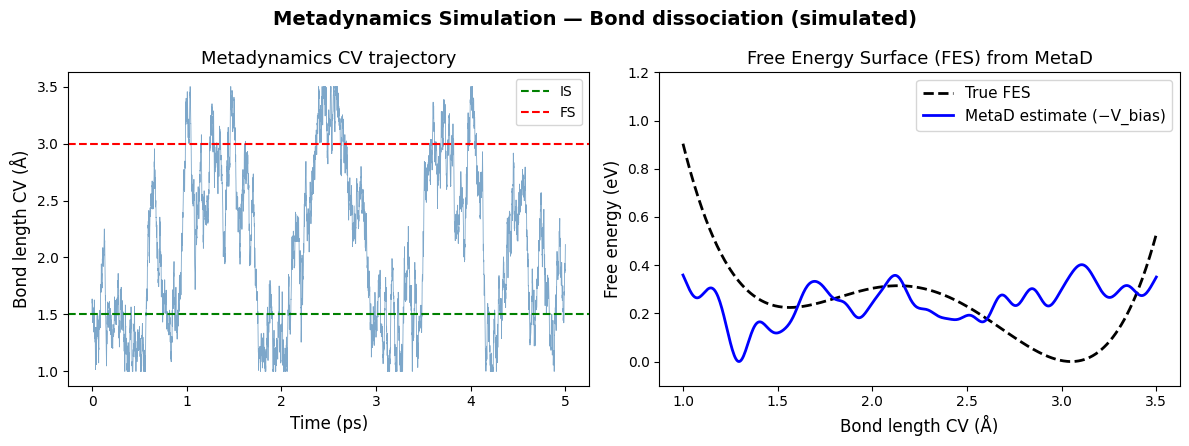

Left panel: CV visits both IS and FS regions once bias fills the well.
Right panel: Accumulated bias (−V_bias) approximates the true FES.


In [3]:
import numpy as np
import matplotlib.pyplot as plt

# ---------- Simulate a metadynamics trajectory ----------
# In a real workflow: parse vaspout.dat / REPORT / HILLS file

np.random.seed(7)
n_steps = 5000

# Simulated free energy surface: double-well in CV (bond length Å)
cv_range = np.linspace(1.0, 3.5, 500)

def true_fes(cv):
    """Double-well free energy (arbitrary units, eV)"""
    return 0.6 * (cv - 1.5)**2 * (cv - 3.0)**2 - 0.15 * (cv - 2.0)

true_FES = true_fes(cv_range)

# Simulate biased trajectory (simplified)
cv_traj = [1.5]  # start at IS
bias = np.zeros(len(cv_range))
W, sigma, stride = 0.04, 0.05, 50

for step in range(1, n_steps):
    cv_current = cv_traj[-1]
    # Effective force from FES + bias gradient (simplified random walk)
    idx = np.argmin(np.abs(cv_range - cv_current))
    fes_grad = np.gradient(true_FES + bias, cv_range)[idx]
    noise = np.random.normal(0, 0.08)
    cv_new = np.clip(cv_current - 0.005 * fes_grad + noise, cv_range[0], cv_range[-1])
    cv_traj.append(cv_new)
    if step % stride == 0:
        bias += W * np.exp(-0.5 * ((cv_range - cv_current) / sigma)**2)

cv_traj = np.array(cv_traj)
estimated_FES = -bias   # MetaD FES estimate
estimated_FES -= estimated_FES.min()

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Trajectory plot
axes[0].plot(np.arange(n_steps) * 1e-3, cv_traj, alpha=0.7, lw=0.6, color='steelblue')
axes[0].set_xlabel('Time (ps)', fontsize=12)
axes[0].set_ylabel('Bond length CV (Å)', fontsize=12)
axes[0].set_title('Metadynamics CV trajectory', fontsize=13)
axes[0].axhline(1.5, color='green', ls='--', label='IS', lw=1.5)
axes[0].axhline(3.0, color='red',   ls='--', label='FS', lw=1.5)
axes[0].legend()

# FES plot
true_shift = true_FES - true_FES.min()
axes[1].plot(cv_range, true_shift, 'k--', lw=2, label='True FES')
axes[1].plot(cv_range, estimated_FES, 'b-', lw=2, label='MetaD estimate (−V_bias)')
axes[1].set_xlabel('Bond length CV (Å)', fontsize=12)
axes[1].set_ylabel('Free energy (eV)', fontsize=12)
axes[1].set_title('Free Energy Surface (FES) from MetaD', fontsize=13)
axes[1].legend(fontsize=11)
axes[1].set_ylim(-0.1, 1.2)

plt.suptitle('Metadynamics Simulation — Bond dissociation (simulated)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("Left panel: CV visits both IS and FS regions once bias fills the well.")
print("Right panel: Accumulated bias (−V_bias) approximates the true FES.")

### 6.7 Convergence & Best Practices

**Choosing collective variables:**
- The CV must **distinguish reactant from product** — if the CV is poor, sampling will be inefficient
- Start with simple CVs (bond lengths, coordination numbers)
- Consider **path CVs** (progress variable s and deviation z) for complex mechanisms

**Gaussian parameters:**

| Parameter | Typical Value | Effect |
|-----------|---------------|--------|
| Height W | 0.01–0.1 eV | Larger → faster sampling, less accurate FES |
| Width σ | ~10–20% of CV range | Narrower → more accurate features |
| Stride | 20–100 steps | Less frequent → smoother filling |

**Checking convergence:**
- Run multiple independent MetaD runs; FES should agree within kT
- For WT-MetaD: monitor Gaussian heights W(t) → they should decay to ~0
- Compare FES from first half vs. second half of simulation

**Metadynamics vs. NEB:**

| | NEB / CI-NEB | Metadynamics |
|---|---|---|
| Output | Minimum energy path (0 K) | Free energy surface (finite T) |
| Entropy | ❌ Not included | ✅ Included |
| Known endpoints? | Required | Not required |
| Cost | Medium (N_images × VASP) | High (long AIMD) |
| Best use | Precise barriers at 0 K | FES at reaction temperature |

### 6.8 Using PLUMED with VASP

[PLUMED](https://www.plumed.org) is an open-source library that interfaces with VASP (and many other codes) to provide advanced CV definitions and enhanced sampling methods.

**Setup:**
1. Compile PLUMED and patch into VASP source: `plumed patch -p`
2. Add `PLUMED = .TRUE.` to INCAR
3. Write `plumed.dat` file defining CVs and metadynamics parameters

Example `plumed.dat` for WT-MetaD on a bond distance:
```
UNITS LENGTH=A ENERGY=eV TIME=fs

d1: DISTANCE ATOMS=1,2      # Bond length as CV

METAD ARG=d1 SIGMA=0.05 HEIGHT=0.05 BIASFACTOR=10 PACE=50 LABEL=metad
  FILE=HILLS  TEMP=600

PRINT ARG=d1,metad.bias STRIDE=10 FILE=COLVAR
```

---

## 7. Summary & Method Selection Guide

### When to Use Which Method?

```
Do you know both reactant and product?
│
├── YES → NEB/CI-NEB
│         ├── Need approximate path?  → Standard NEB (LCLIMB=.FALSE.)
│         └── Need exact saddle point? → CI-NEB (LCLIMB=.TRUE.)
│
└── NO  → Dimer Method (open-ended TS search)
          Need free energy at T > 0?  → Add Metadynamics
```

### Checklist for a Complete Reaction Mechanism Study

- [ ] Relax IS and FS; confirm they are true minima (no imaginary frequencies)
- [ ] Interpolate images with IDPP (not linear)
- [ ] Run standard NEB → converge band
- [ ] Switch to CI-NEB → converge to exact TS
- [ ] Verify TS: exactly 1 imaginary frequency, mode points along MEP
- [ ] Compute Bader charges along MEP to track electron transfer
- [ ] Optionally: run MetaD to get T-dependent free energy barrier
- [ ] Report: Ea (forward), ΔE_rxn, Ea (reverse), imaginary frequency mode vector

### Key Codes & Resources

| Tool | Purpose | Link |
|------|---------|------|
| VTST (Henkelman group) | NEB, CI-NEB, Dimer in VASP | [theory.cm.utexas.edu/vtsttools](http://theory.cm.utexas.edu/vtsttools) |
| Bader analysis code | Charge partitioning | [theory.cm.utexas.edu/henkelman/code/bader](http://theory.cm.utexas.edu/henkelman/code/bader) |
| ASE (NEB) | Pythonic NEB setup + IDPP | [wiki.fysik.dtu.dk/ase](https://wiki.fysik.dtu.dk/ase) |
| PLUMED | Advanced MetaD CVs | [plumed.org](https://www.plumed.org) |
| vaspkit | Pre/post-processing | [vaspkit.com](https://vaspkit.com) |

### Key References

1. **Bader/AIM:** Henkelman, Arnaldsson, Jónsson, *Comput. Mater. Sci.* **36**, 354 (2006)
2. **NEB:** Jónsson, Mills, Jacobsen, *Classical and Quantum Dynamics in Condensed Phase Simulations* (1998)
3. **CI-NEB:** Henkelman, Uberuaga, Jónsson, *J. Chem. Phys.* **113**, 9901 (2000)
4. **Dimer Method:** Henkelman & Jónsson, *J. Chem. Phys.* **111**, 7010 (1999)
5. **Improved Dimer:** Heyden, Bell, Keil, *J. Chem. Phys.* **123**, 224101 (2005)
6. **Metadynamics:** Laio & Parrinello, *PNAS* **99**, 12562 (2002)
7. **Well-Tempered MetaD:** Barducci, Bussi, Parrinello, *Phys. Rev. Lett.* **100**, 020603 (2008)

---

*Ch121a | Caltech | Module 3 — Notebook 3b of 6*